
# Network Science - UDD

## Lab 5 | Práctica en compras públicas



#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

Este notebook está pensado como **workflow de proyecto**. No busca repetir toda la práctica general, sino traducir el protocolo ya aprendido a un caso de compras públicas:

- decidir qué grafo construir
- justificar umbrales y proyecciones
- evaluar estabilidad de comunidades
- usar `k-core` y roles de forma útil
- y producir hipótesis de trabajo para el proyecto

---


## Mesoestructura en compras públicas

Aquí el foco ya no es aprender el algoritmo desde cero, sino usarlo con criterio para preguntas de proyecto. El orden correcto es:

1. mirar la bipartita original;
2. decidir si conviene proyectar;
3. evaluar estabilidad de la partición;
4. revisar sensibilidad a umbrales y `resolution`;
5. traducir los resultados a hipótesis y segmentación analítica.


## 0. Librerías y entorno

El notebook asume un entorno razonable de análisis y una convención simple de trabajo.

- Si hace falta instalar dependencias, usa al inicio: `%pip install python-louvain scikit-learn leidenalg igraph`.
- La data debe estar en la carpeta `./data` relativa al notebook.
- Si corres el notebook desde otra carpeta, la carga fallará.
- El backend por defecto del notebook es `Louvain`, porque es suficiente para un flujo de proyecto; si `Leiden` está disponible, se puede contrastar con el mismo protocolo.


In [42]:
from pathlib import Path
import warnings
import math

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from community import community_louvain
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from networkx.algorithms import bipartite

try:
    import igraph as ig
    import leidenalg as la
    LEIDEN_OK = True
except Exception:
    ig = None
    la = None
    LEIDEN_OK = False

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")

# Si hace falta instalar dependencias:
# %pip install python-louvain scikit-learn leidenalg igraph

SEED = 42
np.random.seed(SEED)
SKLEARN_OK = True

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
if hasattr(sns, "set_theme"):
    sns.set_theme(style="whitegrid", context="talk")
else:
    sns.set_style("whitegrid")
    sns.set_context("talk")


## 1. Carga de datos y supuestos

La lógica de análisis será la siguiente:

1. cargar una red **empresa–licitación**;
2. elegir un subconjunto manejable para docencia;
3. dejar explícito qué estamos filtrando y por qué;
4. construir primero la **red bipartita original** y solo después una **proyección proveedor–proveedor**.

Esto sigue el espíritu de **Latapy, Magnien & Del Vecchio (2008)**: la proyección es útil, pero nunca debe ocultar la estructura bipartita que la genera.


In [43]:
DATA_DIR = Path("./data")
REQUIRED_FILES = ["Bipartite Bid Data.csv", "Tender Data.csv", "Firm Data.csv"]

missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        "No se encontraron los archivos esperados en ./data. " 
        "Corre este notebook desde la carpeta 'Lab 5 - Mesoestructura' y verifica que existan: " 
        + ", ".join(missing)
    )

bids_raw = pd.read_csv(DATA_DIR / "Bipartite Bid Data.csv")
tender_raw = pd.read_csv(DATA_DIR / "Tender Data.csv")
firm_raw = pd.read_csv(DATA_DIR / "Firm Data.csv")
load_meta = {"source": "./data", "data_dir": str(DATA_DIR.resolve())}

print(load_meta)
print("bids:", bids_raw.shape)
print("tender:", tender_raw.shape)
print("firm:", firm_raw.shape)
display(bids_raw.head())


{'source': './data', 'data_dir': '/Users/crcandia/Dropbox (Personal)/Cursos_UDD/Redes y Sistemas Complejos/runs/2026-1-MDS/overrides/labs/Lab 5 - Mesoestructura/data'}
bids: (196608, 5)
tender: (39523, 5)
firm: (1906, 13)


,MUNICIPALITY,TENDER,FIRMS,WINNER,YEAR
0,M_100,BID_140219,COM_25874,1,2015
1,M_100,BID_140219,COM_27968,0,2015
2,M_100,BID_140219,COM_29841,1,2015
3,M_100,BID_140219,COM_31345,1,2015
4,M_100,BID_140219,COM_40979,0,2015


### Selección del subconjunto de trabajo

Si usamos la base real del curso, tomaremos un subconjunto **municipio-año** que sea:

- suficientemente grande para que exista mesoestructura;
- suficientemente acotado para que el laboratorio sea legible;
- compatible con visualización y chequeos de estabilidad en tiempo razonable.

Además, filtraremos licitaciones con **2 a 30 oferentes** para evitar dos problemas pedagógicos frecuentes:

- licitaciones con un solo oferente, que no generan co-participación en la proyección;
- licitaciones muy grandes, que pueden inflar artificialmente densidad y clustering en la proyección.


In [45]:
def choose_teaching_subset(bids):
    if {"MUNICIPALITY", "YEAR", "TENDER", "FIRMS"}.issubset(bids.columns):
        # Preferimos un caso que ya sabemos funciona bien en la base del curso.
        # mask = (bids["MUNICIPALITY"] == "M_57") & (bids["YEAR"] == 2019)
        mask =  (bids["YEAR"] == 2019)
        if mask.any():
            return bids.loc[mask].copy(), {"municipality": "M_57", "year": 2019, "selection": "fixed_demo_case"}

        # Fallback: buscamos un municipio-año manejable para docencia.
        candidates = []
        for (year, municipality), g in bids.groupby(["YEAR", "MUNICIPALITY"]):
            tender_size = g.groupby("TENDER")["FIRMS"].nunique()
            keep = tender_size[(tender_size >= 2) ].index#& (tender_size <= 30)
            filtered = g[g["TENDER"].isin(keep)]
            n_tenders = filtered["TENDER"].nunique()
            n_firms = filtered["FIRMS"].nunique()
            if 80 <= n_tenders <= 350 and 150 <= n_firms <= 1500:
                candidates.append((n_tenders, n_firms, year, municipality))

        if candidates:
            _, _, year, municipality = sorted(candidates, reverse=True)[0]
            mask = (bids["MUNICIPALITY"] == municipality) & (bids["YEAR"] == year)
            return bids.loc[mask].copy(), {"municipality": municipality, "year": year, "selection": "largest_teaching_case"}

    return bids.copy(), {"municipality": "all", "year": "all", "selection": "synthetic_or_full"}


def filter_tender_size(df, min_bidders=2, max_bidders=30):
    tender_size = df.groupby("TENDER")["FIRMS"].nunique()
    keep_tenders = tender_size[(tender_size >= min_bidders) & (tender_size <= max_bidders)].index
    return df[df["TENDER"].isin(keep_tenders)].copy()


bids_subset, subset_meta = choose_teaching_subset(bids_raw)
bids = filter_tender_size(bids_subset, min_bidders=2, max_bidders=30)
annot = bids.merge(tender_raw, on=[c for c in ["TENDER", "YEAR"] if c in tender_raw.columns], how="left")

summary = pd.DataFrame(
    {
        "rows": [len(bids)],
        "municipality": [subset_meta["municipality"]],
        "year": [subset_meta["year"]],
        "tenders": [bids["TENDER"].nunique()],
        "firms": [bids["FIRMS"].nunique()],
        "avg firms per tender": [round(bids.groupby("TENDER")["FIRMS"].nunique().mean(), 2)],
        "share winners=1": [round(bids["WINNER"].mean(), 3)] if "WINNER" in bids.columns else [np.nan],
    }
)

display(summary)
print("source:", load_meta["source"], "| subset selection:", subset_meta["selection"])
print("missing tender TYPE share:", round(annot.get("TYPE", pd.Series(dtype=float)).isna().mean() if "TYPE" in annot else np.nan, 3))

,rows,municipality,year,tenders,firms,avg firms per tender,share winners=1
0,26525,M_57,2019,5283,7566,5.02,0.449


source: ./data | subset selection: fixed_demo_case
missing tender TYPE share: 0.197


## 2. Visualización inicial de la estructura

Antes de hablar de comunidades o `k-core`, conviene mirar algunas propiedades simples:

- cuántas firmas compiten por licitación;
- cuántas licitaciones atiende cada firma;
- cuán heterogéneo es ese patrón.

Esto ya entrega información sustantiva útil y, además, anticipa problemas de proyección.


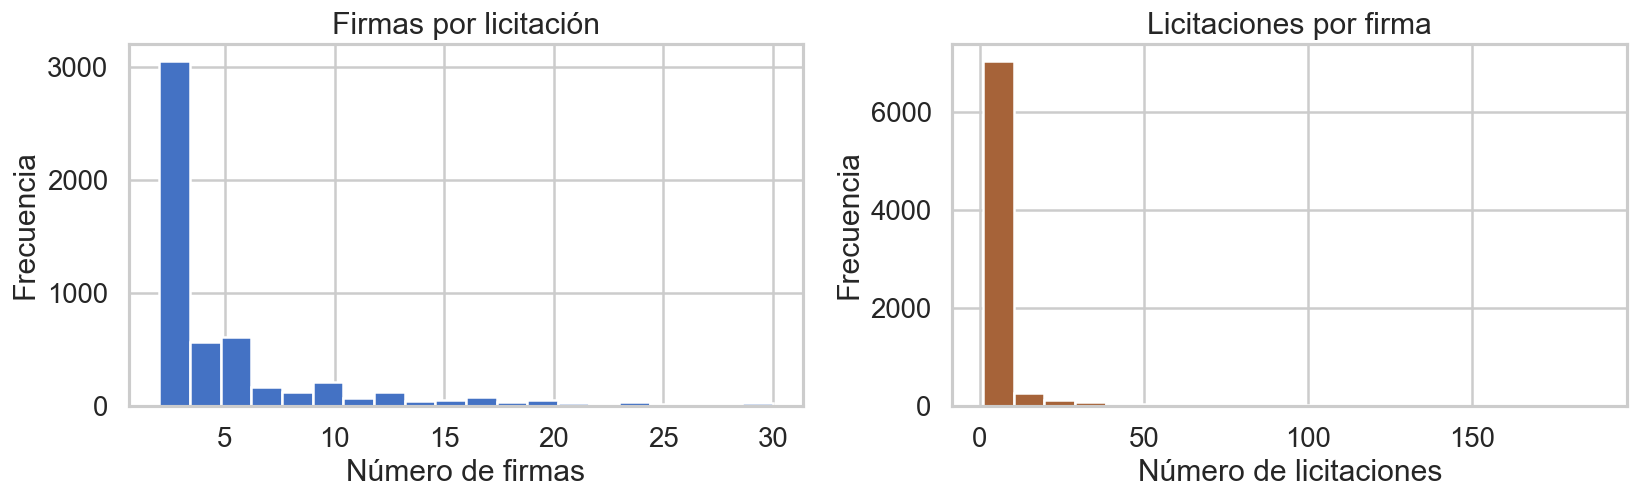

,metric,value
0,tenders,5283.0
1,firms,7566.0
2,median firms/tender,3.0
3,p90 firms/tender,11.0
4,median tenders/firm,1.0
5,p90 tenders/firm,7.0


Top 10 firms by number of tenders:


,tenders
FIRMS,
COM_40482,188
COM_29301,186
COM_31825,121
COM_36735,118
COM_33851,117
COM_30520,107
COM_35585,105
COM_26948,97
COM_31999,96


In [46]:
tender_size = bids.groupby("TENDER")["FIRMS"].nunique().sort_values(ascending=False)
firm_degree_bip = bids.groupby("FIRMS")["TENDER"].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(tender_size.values, bins=20, color="#4472C4", edgecolor="white")
axes[0].set_title("Firmas por licitación")
axes[0].set_xlabel("Número de firmas")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(firm_degree_bip.values, bins=20, color="#A66339", edgecolor="white")
axes[1].set_title("Licitaciones por firma")
axes[1].set_xlabel("Número de licitaciones")
axes[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

stats_table = pd.DataFrame(
    {
        "metric": [
            "tenders",
            "firms",
            "median firms/tender",
            "p90 firms/tender",
            "median tenders/firm",
            "p90 tenders/firm",
        ],
        "value": [
            bids["TENDER"].nunique(),
            bids["FIRMS"].nunique(),
            tender_size.median(),
            tender_size.quantile(0.90),
            firm_degree_bip.median(),
            firm_degree_bip.quantile(0.90),
        ],
    }
)

display(stats_table)
print("Top 10 firms by number of tenders:")
display(firm_degree_bip.head(10).rename("tenders").to_frame())

### Construcción de la red bipartita original

Aquí la interpretación es directa:

- nodos de tipo `firm` = proveedores;
- nodos de tipo `tender` = licitaciones;
- una arista indica participación de una firma en una licitación.

Esta es la estructura que queremos **preservar conceptualmente**, incluso si luego proyectamos para ciertas preguntas.


,metric,value
0,nodes,12849.000000
1,edges,26525.000000
2,firms,7566.000000
3,tenders,5283.000000
4,density,0.000664
5,components,490.000000


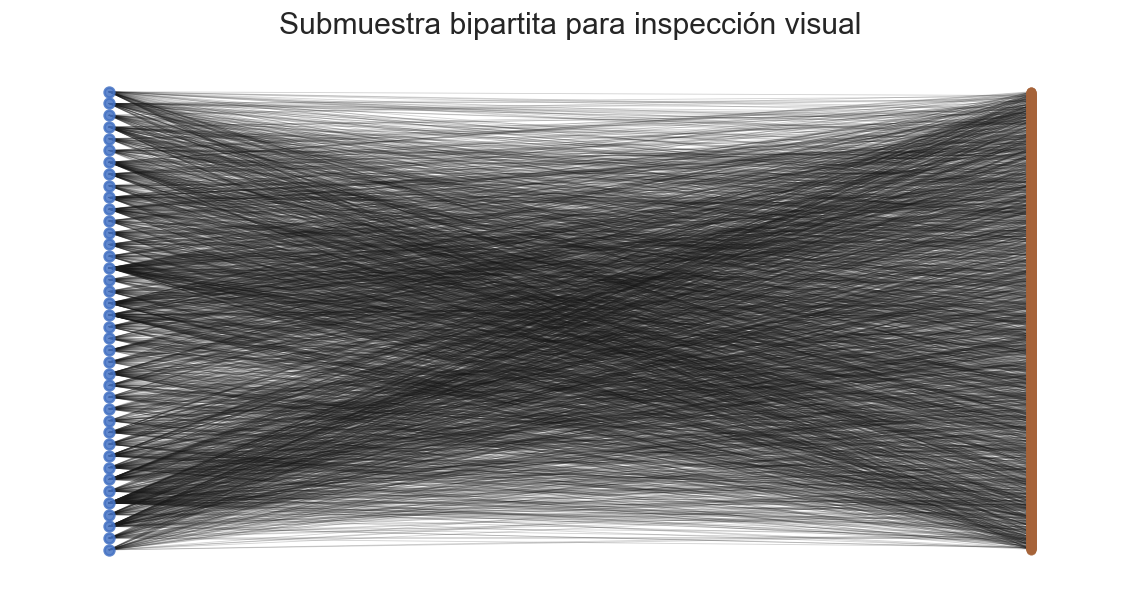

In [47]:
def build_bipartite_graph(df):
    B = nx.Graph()
    B.add_nodes_from(df["FIRMS"].unique(), bipartite="firm")
    B.add_nodes_from(df["TENDER"].unique(), bipartite="tender")
    B.add_edges_from(df[["FIRMS", "TENDER"]].itertuples(index=False, name=None))
    return B


def giant_component_nodes(G):
    if G.number_of_nodes() == 0:
        return []
    components = list(nx.connected_components(G))
    return max(components, key=len)


B = build_bipartite_graph(bids)
firm_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "firm"]
tender_nodes = [n for n, d in B.nodes(data=True) if d["bipartite"] == "tender"]

bip_stats = pd.DataFrame(
    {
        "metric": ["nodes", "edges", "firms", "tenders", "density", "components"],
        "value": [
            B.number_of_nodes(),
            B.number_of_edges(),
            len(firm_nodes),
            len(tender_nodes),
            bipartite.density(B, firm_nodes),
            nx.number_connected_components(B),
        ],
    }
)

display(bip_stats)

# Para visualizar, mostramos una subred docente: firmas de mayor grado + sus licitaciones vecinas.
top_firms = set(firm_degree_bip.head(min(40, len(firm_degree_bip))).index)
neighbor_tenders = {nbr for firm in top_firms for nbr in B.neighbors(firm)}
B_small = B.subgraph(top_firms | neighbor_tenders).copy()

fig, ax = plt.subplots(figsize=(12, 6))
pos = nx.bipartite_layout(B_small, list(top_firms), align="vertical", scale=2)
firm_small = [n for n in B_small if B_small.nodes[n]["bipartite"] == "firm"]
tender_small = [n for n in B_small if B_small.nodes[n]["bipartite"] == "tender"]

nx.draw_networkx_nodes(B_small, pos, nodelist=firm_small, node_color="#4472C4", node_size=35, alpha=0.85, ax=ax)
nx.draw_networkx_nodes(B_small, pos, nodelist=tender_small, node_color="#A66339", node_size=20, alpha=0.60, ax=ax)
nx.draw_networkx_edges(B_small, pos, width=0.5, alpha=0.20, ax=ax)
ax.set_title("Submuestra bipartita para inspección visual")
ax.axis("off")
plt.show()

## 3. De la bipartita a la proyección proveedor–proveedor

Ahora hacemos una proyección sobre el modo `firm`.

Dos proveedores quedan conectados si participaron en al menos una misma licitación.

### Importante
Eso **no** significa que estén “relacionados” en un sentido sustantivo fuerte. Significa, más modestamente, que **co-participaron** en el mismo evento de compra.

Para no depender de una sola decisión, comparamos varios **umbrales de peso**.


In [33]:
def build_firm_projection(B, firms, min_weight=1):
    G = bipartite.weighted_projected_graph(B, firms)
    H = nx.Graph((u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= min_weight)
    H.remove_nodes_from(list(nx.isolates(H)))
    return H


def partition_to_communities(partition):
    groups = {}
    for node, com in partition.items():
        groups.setdefault(com, set()).add(node)
    return list(groups.values())


def partition_modularity(G, partition):
    return nx.algorithms.community.quality.modularity(G, partition_to_communities(partition), weight="weight")


def nx_to_igraph(G):
    nodes = list(G.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}
    edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]
    g = ig.Graph(n=len(nodes), edges=edges, directed=False)
    g.es["weight"] = [G[u][v].get("weight", 1.0) for u, v in G.edges()]
    return g, nodes


def run_louvain_partition(G, seed=0, resolution=1.0):
    return community_louvain.best_partition(G, weight="weight", random_state=seed, resolution=resolution)


def run_leiden_partition(G, seed=0, resolution=1.0):
    if not LEIDEN_OK:
        raise RuntimeError("Leiden no está disponible en este entorno.")
    g, nodes = nx_to_igraph(G)
    partition = la.find_partition(
        g,
        la.RBConfigurationVertexPartition,
        weights=g.es["weight"],
        resolution_parameter=resolution,
        seed=seed,
    )
    return {node: partition.membership[i] for i, node in enumerate(nodes)}


def best_partition_single(G, seed=0, resolution=1.0, method="louvain"):
    if method == "leiden":
        part = run_leiden_partition(G, seed=seed, resolution=resolution)
    else:
        part = run_louvain_partition(G, seed=seed, resolution=resolution)
    Q = partition_modularity(G, part)
    return part, Q


METHOD = "louvain"
if LEIDEN_OK:
    print("Leiden está disponible, pero el notebook mantiene Louvain por defecto para comparabilidad entre proyectos.")
else:
    print("Leiden no está disponible; usamos Louvain como backend práctico.")

threshold_rows = []
for threshold in [1, 2, 3]:
    Gt = build_firm_projection(B, firm_nodes, min_weight=threshold)
    if Gt.number_of_nodes() == 0 or Gt.number_of_edges() == 0:
        continue
    largest = Gt.subgraph(giant_component_nodes(Gt)).copy()
    part, Q = best_partition_single(largest, seed=0, resolution=1.0, method=METHOD)
    threshold_rows.append(
        {
            "weight_threshold": threshold,
            "nodes_total": Gt.number_of_nodes(),
            "edges_total": Gt.number_of_edges(),
            "largest_component_nodes": largest.number_of_nodes(),
            "largest_component_edges": largest.number_of_edges(),
            "density_lcc": round(nx.density(largest), 4),
            "communities_lcc": len(set(part.values())),
            "modularity_lcc": round(Q, 4),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)


Leiden está disponible, pero el notebook mantiene Louvain por defecto para comparabilidad entre proyectos.


,weight_threshold,nodes_total,edges_total,largest_component_nodes,largest_component_edges,density_lcc,communities_lcc,modularity_lcc
0,1,7566,76707,4439,58264,0.0059,34,0.6497
1,2,2130,15746,1628,14079,0.0106,14,0.6881
2,3,1151,6615,1036,6535,0.0122,12,0.7145


### Decisión de trabajo para el lab

Para continuar, tomaremos **peso mínimo = 2** en la proyección proveedor–proveedor.

¿Por qué?

- reduce vínculos extremadamente débiles de co-participación;
- mantiene una componente principal suficientemente grande;
- hace más legible la visualización y la interpretación comunitaria.

No es la única decisión posible. Justamente por eso luego proponemos ejercicios para cambiar este umbral.


,metric,value
0,nodes total,2130.0000
1,edges total,15746.0000
2,largest component nodes,1628.0000
3,largest component edges,14079.0000
4,density lcc,0.0106


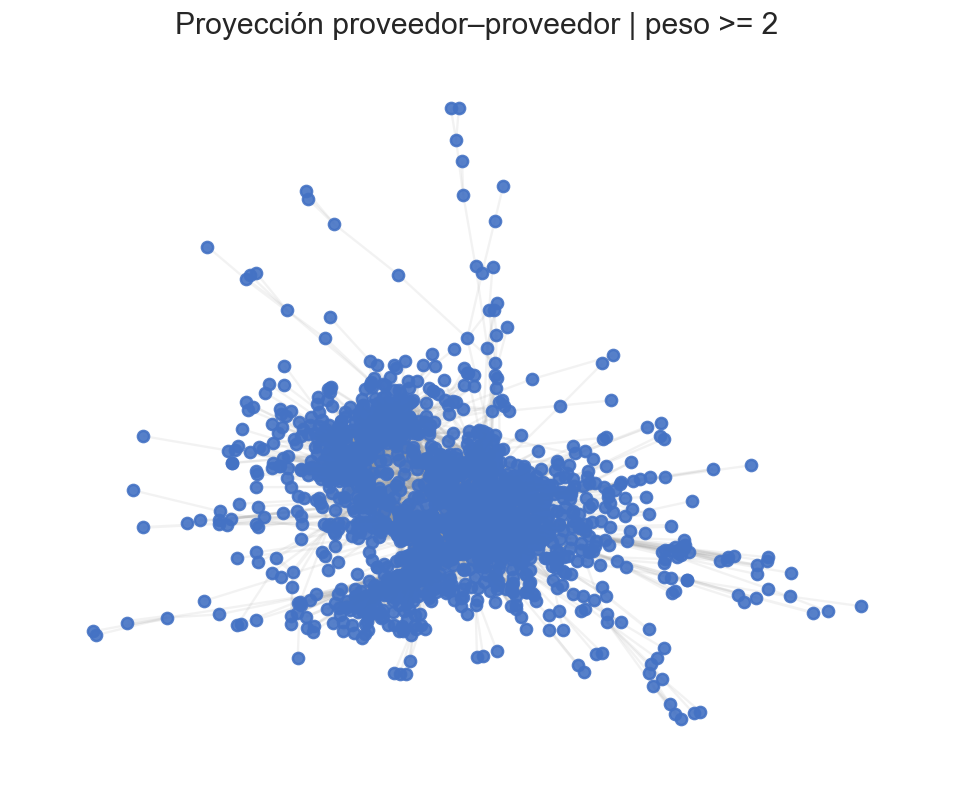

In [34]:
WEIGHT_THRESHOLD = 2
G = build_firm_projection(B, firm_nodes, min_weight=WEIGHT_THRESHOLD)
H = G.subgraph(giant_component_nodes(G)).copy()

proj_stats = pd.DataFrame(
    {
        "metric": ["nodes total", "edges total", "largest component nodes", "largest component edges", "density lcc"],
        "value": [G.number_of_nodes(), G.number_of_edges(), H.number_of_nodes(), H.number_of_edges(), round(nx.density(H), 4)],
    }
)
display(proj_stats)

pos_H = nx.spring_layout(H, seed=SEED, weight="weight")
edge_w = np.array([d.get("weight", 1) for _, _, d in H.edges(data=True)])

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(H, pos_H, alpha=0.12, width=0.7 + 0.35 * edge_w, edge_color="#999999", ax=ax)
nx.draw_networkx_nodes(H, pos_H, node_size=45, node_color="#4472C4", alpha=0.9, ax=ax)
ax.set_title(f"Proyección proveedor–proveedor | peso >= {WEIGHT_THRESHOLD}")
ax.axis("off")
plt.show()

## 4. Detección de comunidades

En este notebook usamos `Louvain` como backend por defecto para mantener el flujo simple y comparable entre proyectos.

La regla metodológica sigue siendo la de la teoría:

- la proyección define qué estructura estás buscando;
- múltiples `seeds` permiten evaluar estabilidad computacional;
- la partición que se interpreta debe ser una **partición representativa**, no la corrida con mayor `Q` elegida a posteriori;
- si luego comparas con `Leiden`, el protocolo debe ser el mismo.


,seed,modularity,n_communities,largest_community
0,0,0.688055,14,307
1,1,0.686882,14,450
2,2,0.688754,19,485
3,3,0.686887,16,386
4,4,0.685067,14,307
5,5,0.687725,13,383
6,6,0.688877,14,514
7,7,0.687471,13,517
8,8,0.685398,14,375
9,9,0.689130,14,284


,backend,reference_seed,mean_ARI_between_seeds,mean_NMI_between_seeds,mean_modularity,std_modularity
0,louvain,3,0.7539,0.8482,0.6874,0.0013


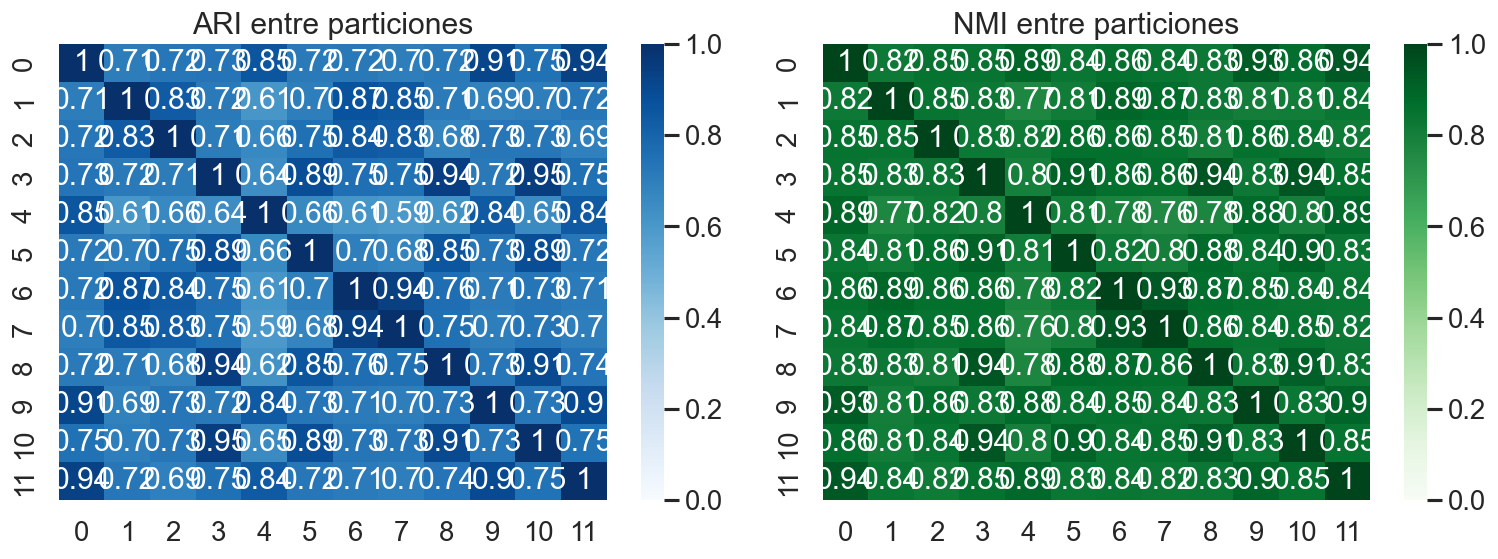

In [35]:
def agreement_matrices(partitions):
    seeds = list(partitions.keys())
    node_order = list(H.nodes())
    ari = pd.DataFrame(index=seeds, columns=seeds, dtype=float)
    nmi = pd.DataFrame(index=seeds, columns=seeds, dtype=float)
    for s1 in seeds:
        for s2 in seeds:
            labels1 = [partitions[s1][n] for n in node_order]
            labels2 = [partitions[s2][n] for n in node_order]
            ari.loc[s1, s2] = adjusted_rand_score(labels1, labels2)
            nmi.loc[s1, s2] = normalized_mutual_info_score(labels1, labels2)
    return ari, nmi


def mean_offdiag(df):
    values = df.to_numpy(dtype=float)
    mask = np.triu(np.ones_like(values, dtype=bool), k=1)
    return float(np.nanmean(values[mask]))


def representative_seed(partitions, metric="ARI"):
    ari, nmi = agreement_matrices(partitions)
    matrix = ari if metric.upper() == "ARI" else nmi
    mean_agreement = {}
    for seed in matrix.index:
        mean_agreement[int(seed)] = float(matrix.loc[seed].drop(seed).mean())
    best_seed = max(mean_agreement, key=mean_agreement.get)
    return int(best_seed), mean_agreement, ari, nmi


def run_multiple_partitions(G, seeds=range(10), resolution=1.0, method="louvain"):
    rows = []
    partitions = {}
    for seed in seeds:
        part, Q = best_partition_single(G, seed=seed, resolution=resolution, method=method)
        sizes = pd.Series(part).value_counts().sort_values(ascending=False).tolist()
        partitions[seed] = part
        rows.append(
            {
                "seed": seed,
                "modularity": Q,
                "n_communities": len(set(part.values())),
                "largest_community": sizes[0],
                "community_sizes": sizes,
            }
        )
    return pd.DataFrame(rows), partitions


results_df, partitions = run_multiple_partitions(H, seeds=range(12), resolution=1.0, method=METHOD)
reference_seed, seed_agreement, ari, nmi = representative_seed(partitions, metric="ARI")
stability_summary = pd.DataFrame(
    [
        {
            "backend": METHOD,
            "reference_seed": reference_seed,
            "mean_ARI_between_seeds": mean_offdiag(ari),
            "mean_NMI_between_seeds": mean_offdiag(nmi),
            "mean_modularity": results_df["modularity"].mean(),
            "std_modularity": results_df["modularity"].std(),
        }
    ]
)

display(results_df[["seed", "modularity", "n_communities", "largest_community"]])
display(stability_summary.style.format({"mean_ARI_between_seeds": "{:.4f}", "mean_NMI_between_seeds": "{:.4f}", "mean_modularity": "{:.4f}", "std_modularity": "{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(ari.astype(float), annot=True, vmin=0, vmax=1, cmap="Blues", ax=axes[0])
axes[0].set_title("ARI entre particiones")
sns.heatmap(nmi.astype(float), annot=True, vmin=0, vmax=1, cmap="Greens", ax=axes[1])
axes[1].set_title("NMI entre particiones")
plt.tight_layout()
plt.show()


### Lectura de estabilidad

La partición que sigue se elige como **representativa por acuerdo medio** entre corridas, no como la corrida con mayor modularidad.

Esa decisión importa porque:

- reduce el riesgo de `cherry-picking`;
- mantiene correspondencia con la teoría sobre estabilidad y consenso;
- y deja un criterio defendible para proyectos.

Si la estabilidad fuera baja, la conclusión correcta no sería “elegir igual una partición”, sino reportar que la estructura es sensible a la especificación actual.


,nodes
community,
1,386
3,267
0,237
4,172
2,170
5,157
6,101
7,58
10,26


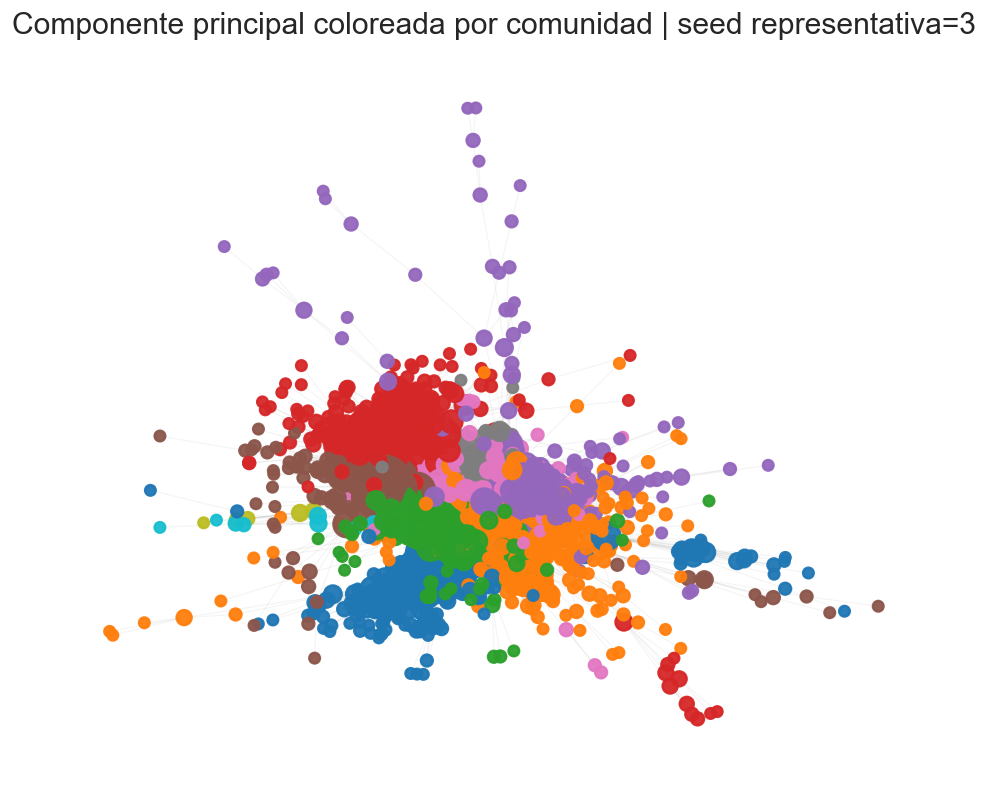

,resolution,modularity,n_communities
0,0.800000,0.6858,13
1,1.000000,0.6869,16
2,1.200000,0.6851,13
3,1.500000,0.6850,15


In [36]:
reference_partition = partitions[int(reference_seed)]
community_series = pd.Series(reference_partition, name="community")
community_sizes = community_series.value_counts().sort_values(ascending=False)

display(community_sizes.rename("nodes").to_frame())

palette = sns.color_palette("tab10", n_colors=len(community_sizes))
color_map = {com: palette[i % len(palette)] for i, com in enumerate(sorted(community_sizes.index))}
node_colors = [color_map[reference_partition[n]] for n in H.nodes()]
node_sizes = [30 + 10 * H.degree(n) for n in H.nodes()]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(H, pos_H, alpha=0.10, width=0.7, edge_color="#999999", ax=ax)
nx.draw_networkx_nodes(H, pos_H, node_color=node_colors, node_size=node_sizes, alpha=0.95, ax=ax)
ax.set_title(f"Componente principal coloreada por comunidad | seed representativa={int(reference_seed)}")
ax.axis("off")
plt.show()

resolution_grid = [0.8, 1.0, 1.2, 1.5]
resolution_rows = []
for gamma in resolution_grid:
    part, Q = best_partition_single(H, seed=int(reference_seed), resolution=gamma, method=METHOD)
    resolution_rows.append(
        {
            "resolution": gamma,
            "modularity": Q,
            "n_communities": len(set(part.values())),
        }
    )
resolution_df = pd.DataFrame(resolution_rows)
display(resolution_df.style.format({"modularity": "{:.4f}"}))


In [37]:
# Resumen sustantivo simple: tipo dominante por comunidad, con advertencia explícita por missingness.
firm_community = community_series.rename_axis("FIRMS").reset_index()
missing_type_share = np.nan

if "TYPE" in annot.columns:
    missing_type_share = float(annot["TYPE"].isna().mean())
    print("TYPE missing share usado para perfilar comunidades:", round(missing_type_share, 3))
    if missing_type_share > 0.15:
        print("Advertencia: la lectura temática es parcial; úsala como hipótesis, no como conclusión.")

    firm_type = (
        annot[["FIRMS", "TYPE"]]
        .dropna()
        .groupby(["FIRMS", "TYPE"])
        .size()
        .reset_index(name="n")
        .sort_values(["FIRMS", "n"], ascending=[True, False])
        .drop_duplicates("FIRMS")
        .rename(columns={"TYPE": "dominant_type"})
        [["FIRMS", "dominant_type"]]
    )
    community_profile = firm_community.merge(firm_type, on="FIRMS", how="left")
    dominant_by_community = (
        community_profile.groupby(["community", "dominant_type"]).size().reset_index(name="firms")
        .sort_values(["community", "firms"], ascending=[True, False])
    )
    display(dominant_by_community.groupby("community").head(5))
else:
    print("No hay metadatos TYPE disponibles para perfilar comunidades.")


TYPE missing share usado para perfilar comunidades: 0.197
Advertencia: la lectura temática es parcial; úsala como hipótesis, no como conclusión.


,community,dominant_type,firms
0,0,ASSETS,85
2,0,CONSUMABLES HEALTH,79
1,0,CONSUMABLES GENERAL,58
4,0,SERVICES,8
3,0,FOOD,4
10,1,FOOD,118
6,1,ASSETS,112
11,1,SERVICES,71
9,1,CONSUMABLES GENERAL,58
7,1,CONSTRUCTION,15


## 5. Core–periphery con `k-core`

En vez de ajustar un modelo complejo de core–periphery, aquí usamos una aproximación simple y útil:

- calcular `core_number` en la proyección proveedor–proveedor;
- leer `coreness` como una medida de **embeddedness** o incrustación estructural;
- combinarla con grado y fuerza para evitar sobreinterpretación.

Siguiendo a **Newman, Networks**, `k-core` es muy valioso precisamente porque es fácil de calcular e interpretar.


,firm,community,core_number,degree,strength
220,COM_31825,5,32,167,1519
898,COM_34189,5,32,131,1000
612,COM_32654,5,32,106,967
131,COM_30520,3,32,182,891
561,COM_35013,5,32,99,812
609,COM_33811,5,32,92,809
574,COM_29672,5,32,105,801
572,COM_32381,5,32,87,786
121,COM_29930,3,32,143,719
567,COM_27426,5,32,91,647


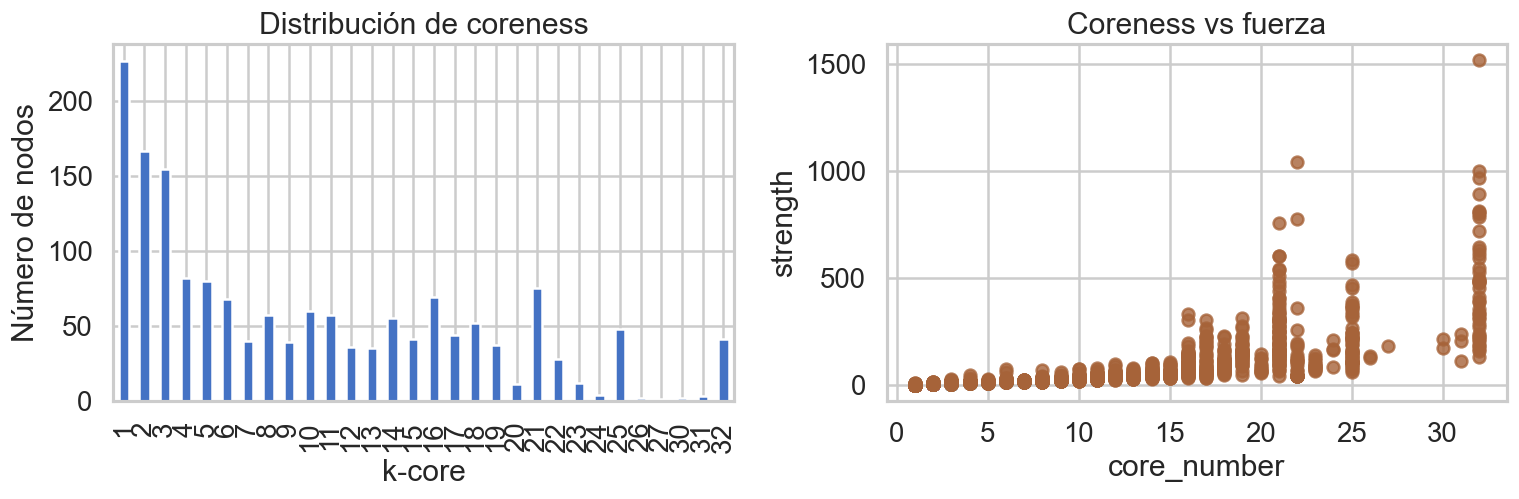

In [38]:
core_number = nx.core_number(H)
strength = dict(H.degree(weight="weight"))
degree = dict(H.degree())

core_df = pd.DataFrame(
    {
        "firm": list(H.nodes()),
        "community": [reference_partition[n] for n in H.nodes()],
        "core_number": [core_number[n] for n in H.nodes()],
        "degree": [degree[n] for n in H.nodes()],
        "strength": [strength[n] for n in H.nodes()],
    }
).sort_values(["core_number", "strength", "degree"], ascending=False)

display(core_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
core_df["core_number"].value_counts().sort_index().plot(kind="bar", color="#4472C4", ax=axes[0])
axes[0].set_title("Distribución de coreness")
axes[0].set_xlabel("k-core")
axes[0].set_ylabel("Número de nodos")

axes[1].scatter(core_df["core_number"], core_df["strength"], s=50, alpha=0.8, color="#A66339")
axes[1].set_title("Coreness vs fuerza")
axes[1].set_xlabel("core_number")
axes[1].set_ylabel("strength")
plt.tight_layout()
plt.show()

### Interpretación cauta del núcleo

Un `core_number` alto puede sugerir:

- firmas muy incrustadas en una región densa del mercado;
- proveedores que aparecen repetidamente en repertorios de licitaciones similares;
- actores con mayor redundancia estructural.

No sugiere por sí solo:

- poder de mercado;
- ventaja indebida;
- coordinación estratégica.


## 6. Roles estructurales simples

Aquí construimos etiquetas **heurísticas** usando cuatro piezas:

- comunidad de referencia;
- `core_number`;
- `betweenness centrality`;
- `participation coefficient` entre comunidades.

Esto no reemplaza blockmodeling ni equivalencia regular formal. Pero sirve muy bien como lectura aplicada y transparente.


,count
role,
periferico_especializado,1078
marginal,360
core_generalista,132
puente_intercomunidad,58


,firm,community,core_number,degree,strength,betweenness,participation,role
268,COM_33851,1,21,180,757,0.073468,0.590836,core_generalista
332,COM_36043,1,21,152,605,0.054609,0.544433,core_generalista
2,COM_29301,0,22,150,1044,0.041666,0.121730,core_generalista
196,COM_33281,2,25,106,469,0.037962,0.387551,core_generalista
131,COM_30520,3,32,182,891,0.035107,0.492900,core_generalista
159,COM_35044,1,21,95,340,0.034235,0.539965,core_generalista
220,COM_31825,5,32,167,1519,0.030859,0.279127,core_generalista
249,COM_28228,4,21,114,405,0.030710,0.537040,core_generalista
771,COM_27340,10,10,26,73,0.030601,0.550948,puente_intercomunidad
914,COM_48422,4,14,23,54,0.026676,0.203018,periferico_especializado


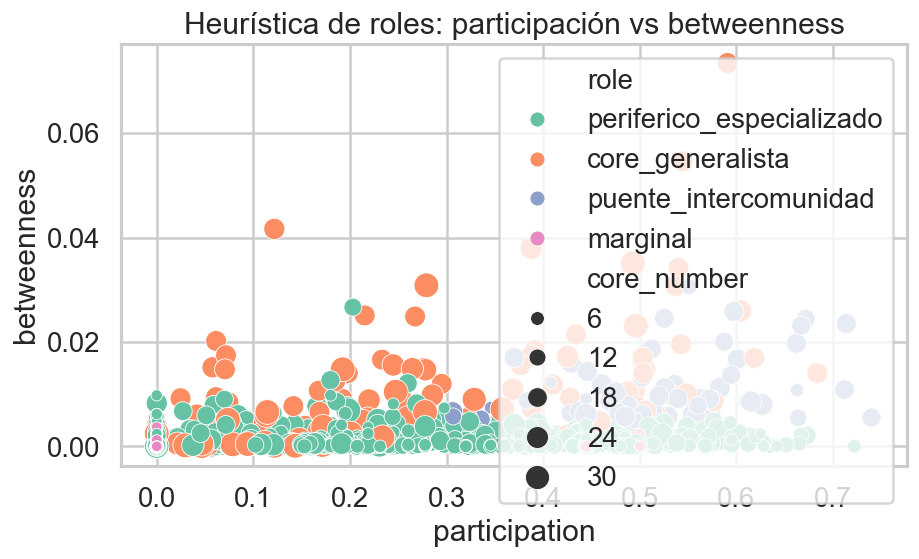

In [39]:
betweenness = nx.betweenness_centrality(H, weight="weight", normalized=True)


def participation_coefficient(G, partition, weight="weight"):
    P = {}
    for node in G.nodes():
        k_i = G.degree(node, weight=weight)
        if k_i == 0:
            P[node] = 0.0
            continue
        by_comm = {}
        for nbr, attrs in G[node].items():
            c = partition[nbr]
            by_comm[c] = by_comm.get(c, 0.0) + attrs.get(weight, 1.0)
        P[node] = 1.0 - sum((v / k_i) ** 2 for v in by_comm.values())
    return P


participation = participation_coefficient(H, reference_partition)

strength_q90 = np.quantile(list(strength.values()), 0.90)
core_q90 = np.quantile(list(core_number.values()), 0.90)
bet_q90 = np.quantile(list(betweenness.values()), 0.90)
part_q75 = np.quantile(list(participation.values()), 0.75)


def label_role(node):
    if degree[node] <= 2 and core_number[node] <= 2:
        return "marginal"
    if core_number[node] >= core_q90 and strength[node] >= strength_q90:
        return "core_generalista"
    if betweenness[node] >= bet_q90 and participation[node] >= part_q75:
        return "puente_intercomunidad"
    return "periferico_especializado"


role_df = pd.DataFrame(
    {
        "firm": list(H.nodes()),
        "community": [reference_partition[n] for n in H.nodes()],
        "core_number": [core_number[n] for n in H.nodes()],
        "degree": [degree[n] for n in H.nodes()],
        "strength": [strength[n] for n in H.nodes()],
        "betweenness": [betweenness[n] for n in H.nodes()],
        "participation": [participation[n] for n in H.nodes()],
    }
)
role_df["role"] = role_df["firm"].map(label_role)

display(role_df["role"].value_counts().rename("count").to_frame())
display(role_df.sort_values(["betweenness", "strength"], ascending=False).head(20))

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=role_df,
    x="participation",
    y="betweenness",
    hue="role",
    size="core_number",
    palette="Set2",
    sizes=(40, 220),
    ax=ax,
)
ax.set_title("Heurística de roles: participación vs betweenness")
plt.tight_layout()
plt.show()

### Cómo leer estas etiquetas

- **core_generalista**: alta incrustación y alta fuerza; suele ser actor transversal dentro de la proyección elegida.
- **periferico_especializado**: poca mezcla entre comunidades y menor embeddedness; puede ser nicho, no irrelevancia.
- **puente_intercomunidad**: mezcla entre comunidades y betweenness relativamente alta; merece inspección cualitativa.
- **marginal**: baja inserción estructural en la componente analizada.

### Advertencia importante
Estas etiquetas son **tentativas**. Cambian si cambia la representación, el umbral o la ventana temporal.


## 7. Interpretación aplicada

Para proyecto, la salida útil no es una historia cerrada, sino un conjunto de hipótesis defendibles.

Ejemplos de preguntas útiles:

- ¿las comunidades parecen segmentos competitivos, segmentos territoriales o mezclas de ambos?
- ¿hay proveedores que queden en posiciones de puente entre módulos?
- ¿el `k-core` alto está concentrado en una sola comunidad o atraviesa varias?
- ¿la lectura cambia mucho al variar umbral o `resolution`?

Productos mínimos que sí sirven para proyecto:

- una tabla de estabilidad;
- una partición representativa claramente justificada;
- un resumen de comunidades con metadatos externos y advertencia de missingness;
- una lectura de `k-core` y roles como hipótesis, no como prueba.


In [40]:
summary_for_discussion = (
    role_df.groupby(["community", "role"]).size().reset_index(name="count")
    .sort_values(["community", "count"], ascending=[True, False])
)
project_handoff = pd.DataFrame(
    [
        {"item": "graph", "value": "supplier-supplier projection from firm-tender bipartite"},
        {"item": "weight_threshold", "value": WEIGHT_THRESHOLD},
        {"item": "community_backend", "value": METHOD},
        {"item": "reference_seed", "value": int(reference_seed)},
        {"item": "mean_ARI_between_seeds", "value": round(mean_offdiag(ari), 4)},
        {"item": "n_reference_communities", "value": len(set(reference_partition.values()))},
        {"item": "max_core_number", "value": int(max(core_number.values()))},
    ]
)

display(summary_for_discussion)
display(project_handoff)

print("Preguntas mínimas para llevar esto al proyecto:")
print("1. ¿Por qué este grafo y no otro?")
print("2. ¿Qué tan estable es la partición?")
print("3. ¿Qué cambia al mover el umbral o la resolution?")
print("4. ¿Qué metadata externa usaré para validar la interpretación?")


,community,role,count
2,0,periferico_especializado,153
1,0,marginal,51
0,0,core_generalista,28
3,0,puente_intercomunidad,5
6,1,periferico_especializado,247
5,1,marginal,100
4,1,core_generalista,24
7,1,puente_intercomunidad,15
10,2,periferico_especializado,120
8,2,core_generalista,26


,item,value
0,graph,supplier-supplier projection from firm-tender ...
1,weight_threshold,2
2,community_backend,louvain
3,reference_seed,3
4,mean_ARI_between_seeds,0.7539
5,n_reference_communities,16
6,max_core_number,32


Preguntas mínimas para llevar esto al proyecto:
1. ¿Por qué este grafo y no otro?
2. ¿Qué tan estable es la partición?
3. ¿Qué cambia al mover el umbral o la resolution?
4. ¿Qué metadata externa usaré para validar la interpretación?


## 8. Mini ejercicios 

1. Cambia `WEIGHT_THRESHOLD` y documenta cómo cambian estabilidad, número de comunidades y lectura sustantiva.
2. Si tienes `Leiden` instalado, reemplaza el backend y compara con `Louvain` usando el mismo protocolo.
3. Repite el análisis con proyección **no ponderada** y explica qué información se pierde.
4. Cambia municipio o año y revisa si la historia es robusta o local.
5. Construye una proyección **comprador–comprador** y compara si las hipótesis sustantivas cambian.
6. Repite el análisis con `WINNER = 1` y discute si estás analizando competencia, adjudicación o ambas cosas.

## Advertencias metodológicas clave

- la proyección simplifica, pero también **pierde información** de la bipartita original;
- alto clustering en una proyección puede emerger por construcción;
- una comunidad estable computacionalmente no equivale automáticamente a una comunidad sustantiva “real”;
- un `k-core` alto no prueba dominancia económica;
- los hallazgos aquí son **exploratorios** y deben cerrarse con triangulación externa.
